In [1]:
#import the relevant functions
from modify_acudata import *
from datetime import datetime

## 1. Running the time shifting operation (for asynchronous acu sim. and detector data streams)

In [6]:
#define the relevant variables

#list of acu g3 files to be modified
flist = ['/mnt/home/ssarkar1/work/workspace/pcam_data/17533/1753319214.g3',
         '/mnt/home/ssarkar1/work/workspace/pcam_data/17533/1753322841.g3']
#location where the modified g3 files will be written
outloc = '/mnt/home/ssarkar1/work/workspace/bookbinder/mock_l2/hk/test2'

#original start time of the acu simulated data streams
otime = 175331923236886368.0 #10ns
#original start time of the detector data streams, acu times will be shifted to
#this time window
mtime = 174976193376301400.0 #10ns


In [7]:
run_timeshift(flist, outloc, otime, mtime)

Processing file: /mnt/home/ssarkar1/work/workspace/pcam_data/17533/1753319214.g3
Reached the end of the file
Processing file: /mnt/home/ssarkar1/work/workspace/pcam_data/17533/1753322841.g3
Reached the end of the file
Done.


In [8]:
#compare the original times and inspect the modified files

print ("Original file time info:")
inspect_file(flist[0])


test_f = outloc+'/1753319214_m.g3'
print ("Modified file time info:")
acu_starttime = inspect_file(test_f)


Original file time info:
start_time: 1753319214.9259322
timestamp: 1753319234.953703
[175331923236886368 175331923237386336 175331923237886464
 175331923238386368 175331923238886368 175331923239386368
 175331923239886432 175331923240386400 175331923240886432
 175331923241386432]
[1.75331923e+09 1.75331923e+09 1.75331923e+09 1.75331923e+09
 1.75331923e+09 1.75331923e+09 1.75331923e+09 1.75331923e+09
 1.75331923e+09 1.75331923e+09]
Modified file time info:
start_time: 1749761916.3200827
timestamp: 1749761936.3478534
[174976193376301408 174976193376801376 174976193377301504
 174976193377801408 174976193378301408 174976193378801408
 174976193379301472 174976193379801440 174976193380301472
 174976193380801472]
[1.74976193e+09 1.74976193e+09 1.74976193e+09 1.74976193e+09
 1.74976193e+09 1.74976193e+09 1.74976193e+09 1.74976193e+09
 1.74976193e+09 1.74976193e+09]


In [9]:
detf = '/mnt/home/ssarkar1/work/workspace/bookbinder/mock_l2/rfsoc/17497/rfsoc5_drone1/r05d1_1749761933_000.g3'
g3f = g3.G3File(detf)

frame = g3f.next()
print ("Detector start time: ", frame['time'])
print ("Shifted ACU data start time: ", datetime.fromtimestamp(acu_starttime))

Detector start time:  12-Jun-2025:20:58:53.996702000
Shifted ACU data start time:  2025-06-12 20:58:36.320083


## 2. Bookbinder trial run from given list of files

In [1]:
import sys
sys.path.append('/mnt/work/ssarkar1/sotodlib/sotodlib/io/')
from bookbinder import *

In [2]:
%load_ext memory_profiler
%load_ext line_profiler

In [3]:
#define the input arguments
rdir = '/mnt/work/ssarkar1/workspace/bookbinder/mock_l2'
odir = '/mnt/home/ssarkar1/work/workspace/bookbinder/mock_books/17533'

hkloc = rdir+'/hk/test2/'
hkfiles = [hkloc+'1753319214_m.g3',
          hkloc+'1753322841_m.g3']

detloc = rdir+'/rfsoc/17497/rfsoc5_drone1/'
detfiles = {'r05d1_1749761933': [detloc+'r05d1_1749761933_000.g3',
                                detloc+'r05d1_1749761933_001.g3',
                                detloc+'r05d1_1749761933_002.g3',
                                detloc+'r05d1_1749761933_003.g3',
                                detloc+'r05d1_1749761933_004.g3',
                                detloc+'r05d1_1749761933_005.g3']}
hkfield = {'az' : 'observatory.acu1.feeds.Azimuth',
           'el' : 'observatory.acu1.feeds.Elevation'}

bb = BookBinder(rdir, odir, hkfield, hkfiles, detfiles, allow_bad_timing=True)
s

In [4]:
#run bookbinding
%%memit
bb.bind(pbar=True)

2025-07-24 03:29:03,357: Preprocessing rfsoc obsid obsID (INFO)
2025-07-24 03:29:26,707: Timestamps are Low Precision, linearizing from frame-counter (WARNING)
2025-07-24 03:29:27,195: Preprocessing HK Data (INFO)
  69.815: Times from acu1.feeds.Azimuth have 3 samples that are not strictly ascending in order. (WARNING)
  69.837: Times from acu1.feeds.Elevation have 3 samples that are not strictly ascending in order. (WARNING)
2025-07-24 03:29:27,699: Finished preprocessing data (INFO)
2025-07-24 03:29:27,701: Binding data to /mnt/home/ssarkar1/work/workspace/bookbinder/mock_books/17533 (INFO)
2025-07-24 03:29:27,703: Binding ancillary data (INFO)


  0%|          | 0/1199 [00:00<?, ?it/s]

2025-07-24 03:29:28,977: Binding rfsoc obsid obsID (INFO)
2025-07-24 03:35:35,023: Finished binding data. Exiting. (INFO)
peak memory: 1514.71 MiB, increment: 1315.66 MiB


## 3. Inspect Book

In [2]:
from glob import glob

In [3]:
bookloc = "/mnt/home/ssarkar1/work/workspace/bookbinder/mock_books/17533/"
bookfiles = sorted(glob(bookloc+"D_*"))

In [4]:
def get_streams(files):
    
    azarr = []
    elarr = []
    Iarr = []
    Qarr = []
    tarr = []
    for file in files:
        print(f"Processing {file}")
        g3f = g3.G3File(file)
        while True:
            try:
                frame = g3f.next()
            except:
                break
            if frame.type == g3.G3FrameType.Scan:
                ancil = frame['ancil']
                signal = frame['signal']
                azarr.append(np.array(ancil['az_enc']))
                elarr.append(np.array(ancil['el_enc']))
                Iarr.append(signal.data[::2][0,:])#only extracting one channel for the purpose of inspection
                Qarr.append(signal.data[1::2][0,:])
                tarr.append(np.array(signal.times)/g3.G3Units.s)#unix
    return np.hstack(azarr), np.hstack(elarr), np.hstack(Iarr), np.hstack(Qarr), np.hstack(tarr)

In [5]:
AZ, EL, dI, dQ, T = get_streams(bookfiles[:2])#using only two files, full book is too large to be handled in single arrays

Processing /mnt/home/ssarkar1/work/workspace/bookbinder/mock_books/17533/D_rfsoc05_drone1_000.g3
Processing /mnt/home/ssarkar1/work/workspace/bookbinder/mock_books/17533/D_rfsoc05_drone1_001.g3


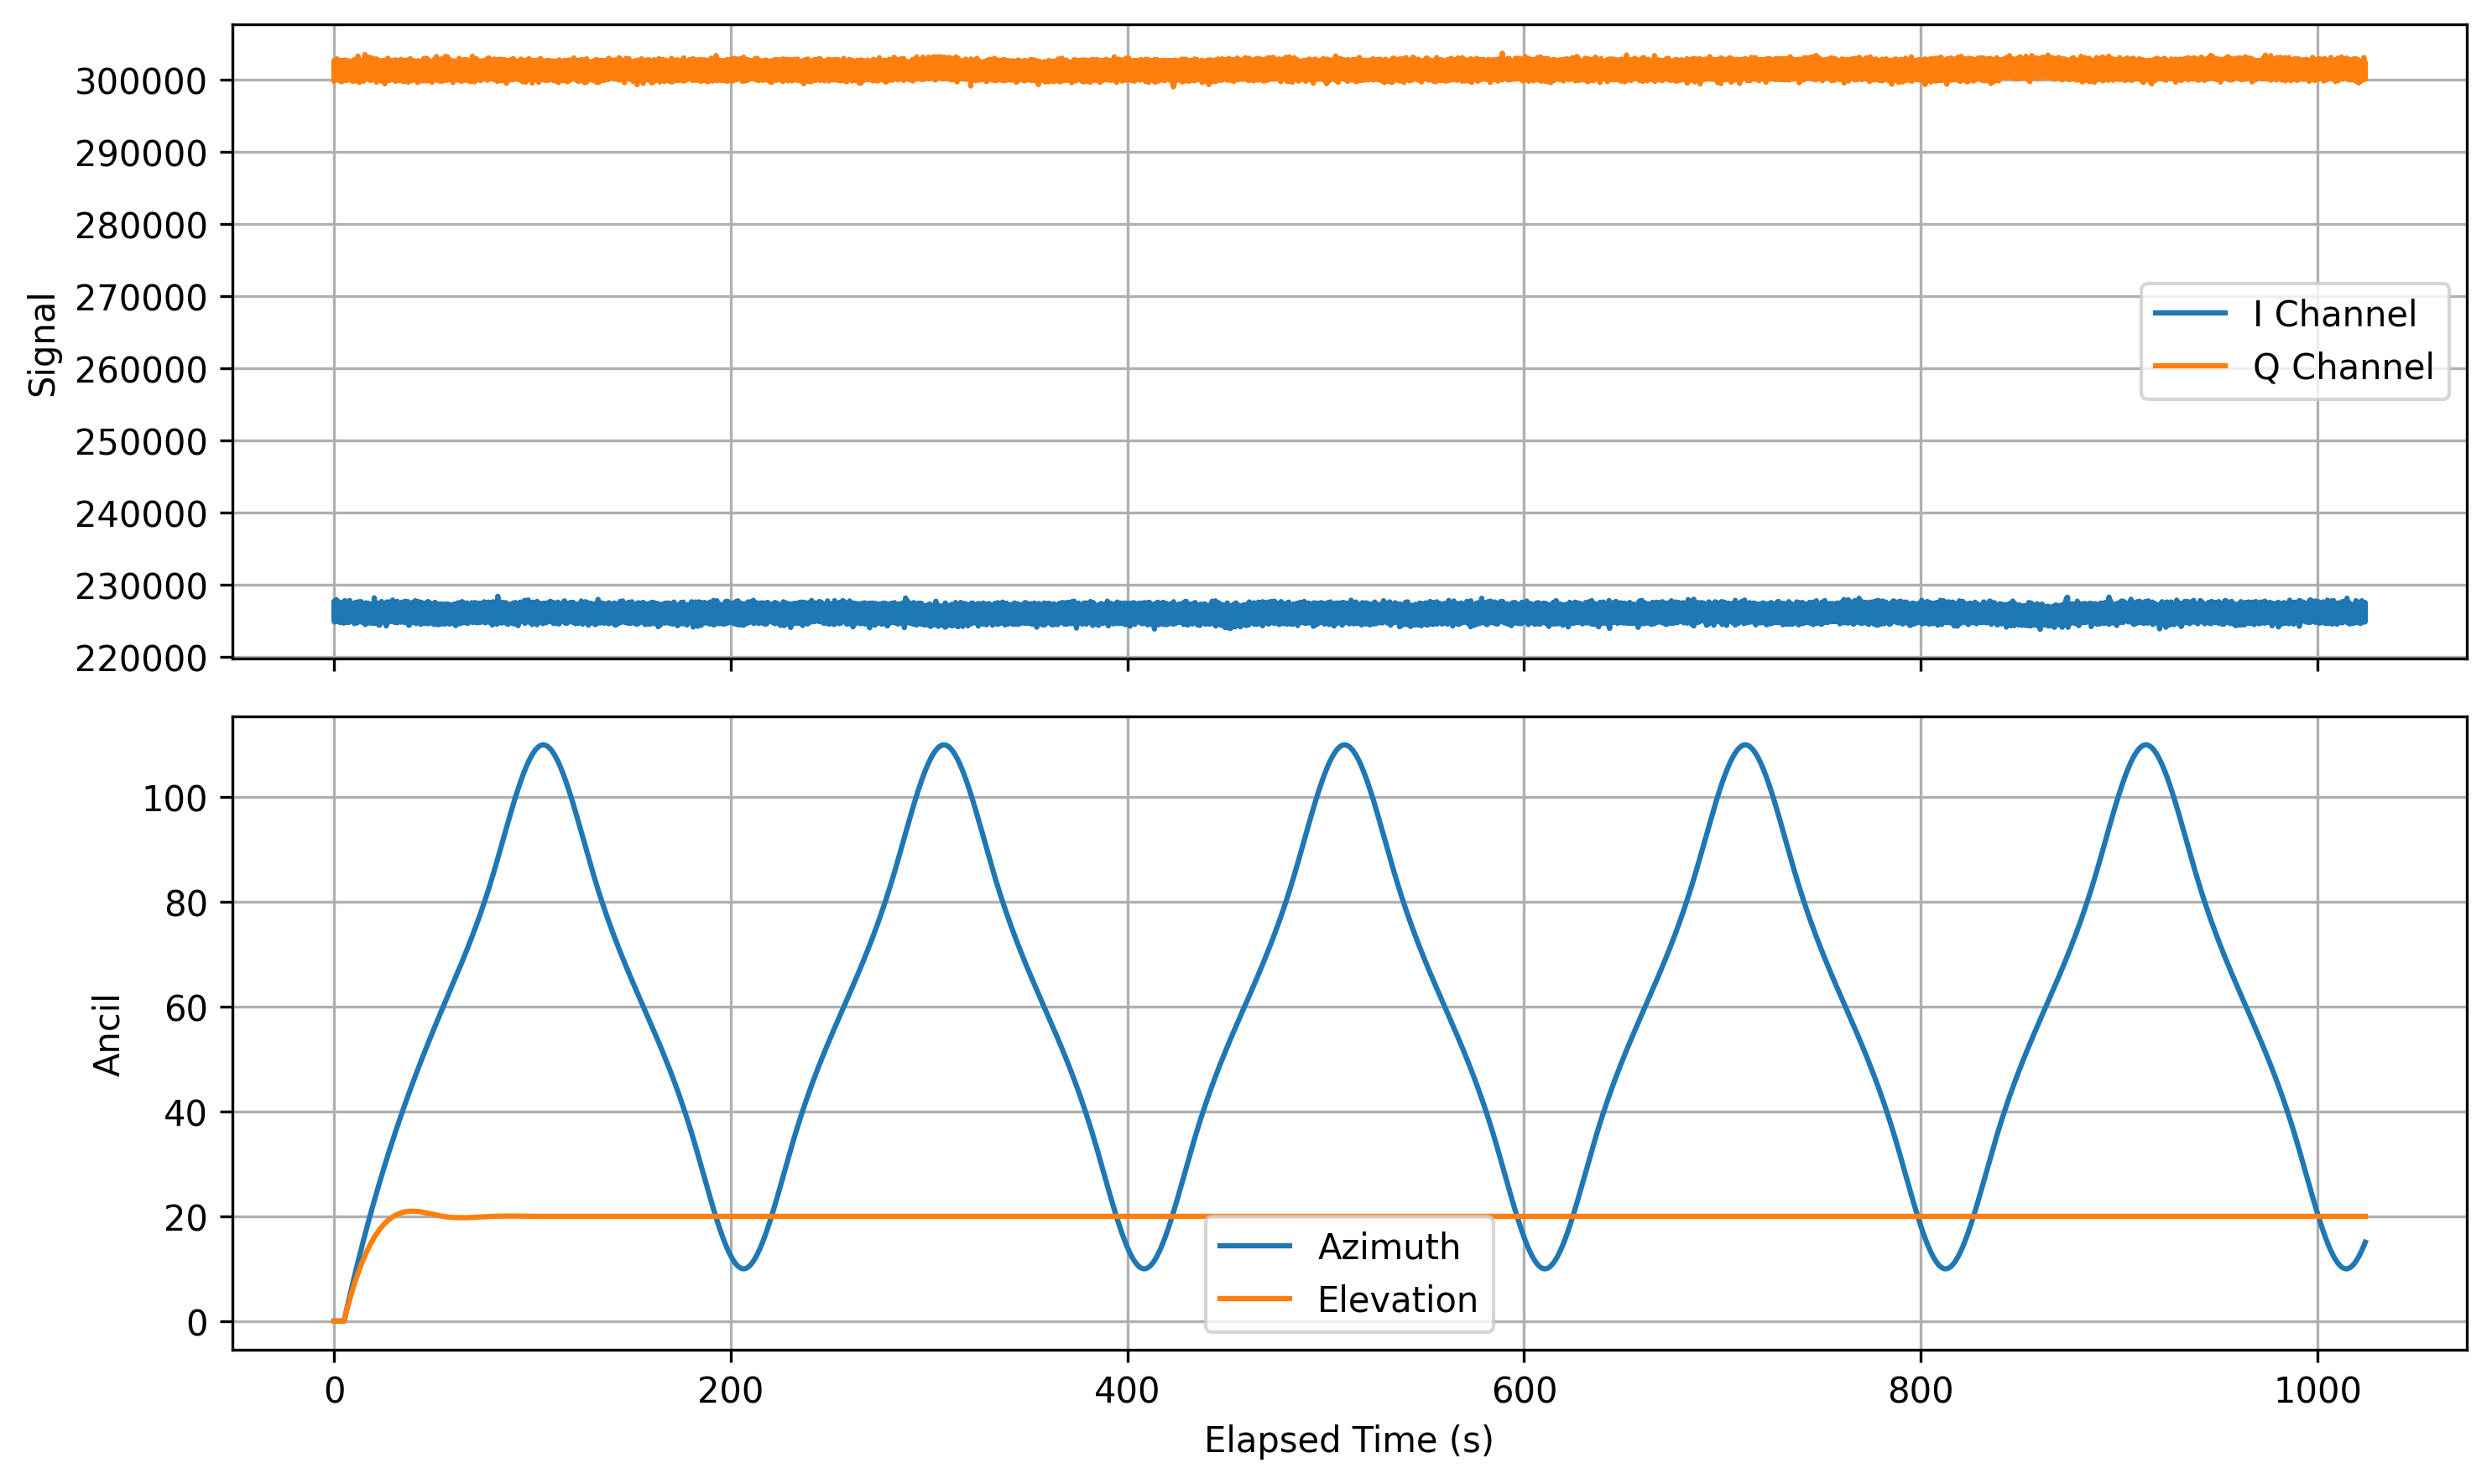

In [7]:
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rc('figure', dpi=300)

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10, 6))

ax1.plot(T-T[0], dI, label='I Channel')
ax1.plot(T-T[0], dQ, label='Q Channel')
ax1.legend()
ax1.grid(True)
ax1.set_ylabel('Signal')

ax2.plot(T-T[0], AZ, label='Azimuth')
ax2.plot(T-T[0], EL, label='Elevation')
ax2.legend()
ax2.grid(True)
ax2.set_ylabel('Ancil')

ax2.set_xlabel('Elapsed Time (s)')

plt.tight_layout()
plt.show()